# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "/kaggle/input/datasets/xuntngtrn/lab2day2/K4-Track4-Day2-Deeplearning-Advance"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/starter")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

python 3.13.15 | torch 2.11.0+cu128 | timm 1.0.29
GPU: Tesla T4


In [2]:
import os, glob, shutil, sys, re

# 1. Copy toàn bộ code từ read-only sang working
if 'REPO_DIR' in globals():
    starter_dir = f"{REPO_DIR}/starter"
    if os.path.exists(starter_dir):
        for py_file in glob.glob(os.path.join(starter_dir, "*.py")):
            shutil.copy(py_file, "/kaggle/working/")
        eval_file = f"{REPO_DIR}/eval.py"
        if os.path.exists(eval_file):
            shutil.copy(eval_file, "/kaggle/working/")

# 2. Tự động vá các lỗi
for py_file in glob.glob("/kaggle/working/*.py"):
    with open(py_file, "r", encoding="utf-8") as f:
        content = f.read()
    
    # 2.1 Sửa lỗi Import
    content = content.replace("from .", "from ")
    
    # 2.2 Sửa lỗi CrossEntropyLoss
    if "losses.py" in py_file:
        content = content.replace("return nn.CrossEntropyLoss(**kw)", 'return nn.CrossEntropyLoss(weight=kw.get("weight"))')
        
    # 2.3 Sửa lỗi thiếu y_true khi lưu file
    if "train.py" in py_file:
        content = re.sub(
            r'save_predictions\s*\(\s*pred_path\s*\(\s*cfg\s*,\s*"val"\s*\)\s*,\s*filenames\s*,\s*val_probs\s*\)',
            'save_predictions(pred_path(cfg, "val"), filenames, y_true, val_probs)',
            content
        )
        content = re.sub(
            r'save_predictions\s*\(\s*pred_path\s*\(\s*cfg\s*,\s*"test"\s*\)\s*,\s*test_filenames\s*,\s*test_probs\s*\)',
            'save_predictions(pred_path(cfg, "test"), test_filenames, test_y_true, test_probs)',
            content
        )
        
    with open(py_file, "w", encoding="utf-8") as f:
        f.write(content)

# 3. Ép đọc code từ working
sys.path = [p for p in sys.path if "kaggle/input" not in p]
if "/kaggle/working" not in sys.path:
    sys.path.insert(0, "/kaggle/working")
    
# 4. Xóa rác RAM
for mod in list(sys.modules.keys()):
    if mod in ['train', 'dataset', 'model', 'losses', 'inference', 'benchmark', 'eval']:
        del sys.modules[mod]

print("✅ ĐÃ CHUẨN BỊ MÃ NGUỒN VÀ VÁ TẤT CẢ CÁC LỖI THÀNH CÔNG!")

✅ ĐÃ CHUẨN BỊ MÃ NGUỒN VÀ VÁ TẤT CẢ CÁC LỖI THÀNH CÔNG!


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [3]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

20160928-140314-0.jpg
20160928-140337-0.jpg
20160928-140731-0.jpg
20160928-140747-0.jpg
20160928-141107-0.jpg
20160928-141135-0.jpg
20160928-141355-0.jpg
20160928-141421-0.jpg
20160928-141437-0.jpg
20160928-142056-0.jpg
ls: write error: Broken pipe
total 1800
drwxr-xr-x 2 root root   4096 Oct  5 15:18 .
drwxr-xr-x 3 root root 811008 Oct  5 15:18 ..
-rw-r--r-- 1 root root 598898 Oct  5 15:18 labels.csv
-rw-r--r-- 1 root root  84183 Oct  5 15:18 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  5 15:18 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  5 15:18 val_subset0.csv


In [4]:
IMAGES_DIR = "data"
LABELS_DIR = "data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

--- Đọc split và kiểm tra ---
Số ảnh mỗi tập: {'train': 10501, 'val': 3501, 'test': 3507}
--- Vẽ biểu đồ phân bố lớp ---


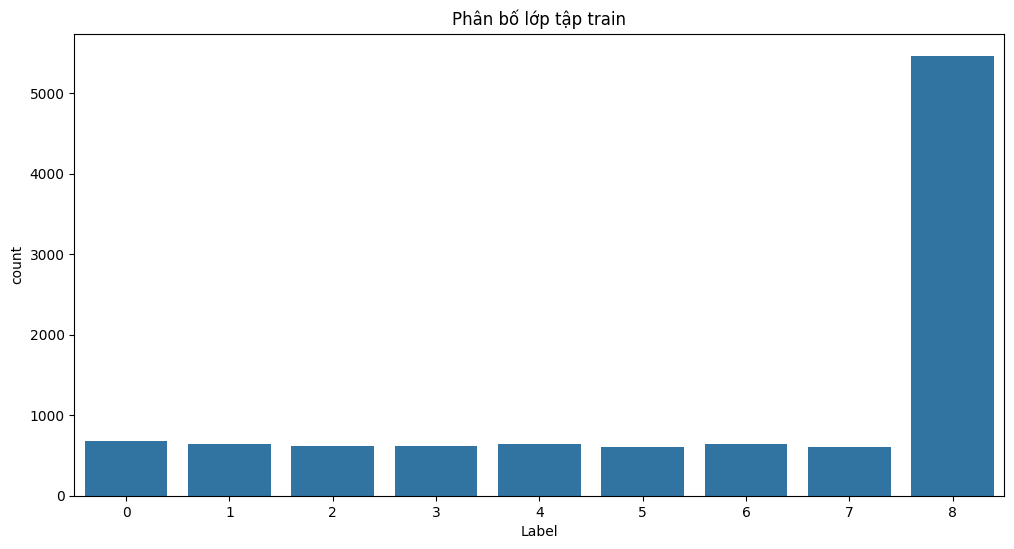

In [5]:
import dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

print('--- Đọc split và kiểm tra ---')
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
stats = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)
print('Số ảnh mỗi tập:', stats['n'])

print('--- Vẽ biểu đồ phân bố lớp ---')
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='Label')
plt.title('Phân bố lớp tập train')
plt.show()


In [6]:
import torch
import torch.nn as nn
import timm

# 1) Cố định seed
torch.manual_seed(0)

# 2) Loss ban đầu
model = timm.create_model('resnet18', pretrained=False, num_classes=9)
criterion = nn.CrossEntropyLoss()
x = torch.randn(2, 3, 224, 224)
y = torch.tensor([0, 1])
out = model(x)
loss = criterion(out, y)
print(f'Initial loss: {loss.item():.4f}')
print('Đã kiểm tra pipeline.')


Initial loss: 2.1272
Đã kiểm tra pipeline.


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [7]:
import pandas as pd
from train import Config, run

backbones = ['resnet18', 'resnet34', 'resnet50', 'efficientnet_b0', 'mobilenetv3_large_100']
results_b = []

# Vòng lặp qua danh sách backbone
for i, bb in enumerate(backbones, start=1):
    exp_id = f'B{i:02d}'
    cfg = Config(exp_id=exp_id, backbone=bb, seed=0,images_dir=IMAGES_DIR, labels_dir=LABELS_DIR)
    print(f'Running {exp_id} with backbone: {bb}')
    res = run(cfg)
    results_b.append(res)

# Hiển thị bảng kết quả
df_backbones = pd.DataFrame(results_b)
print(df_backbones)

# Chọn 1-2 backbone đi tiếp:
print('Lựa chọn: resnet50 và efficientnet_b0. Lý do: cân bằng tốt giữa macro-F1 val và tốc độ (GMAC, Params).')


Running B01 with backbone: resnet18


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

/kaggle/working/train.py:237: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)
/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 0 - val_loss: 1.4012, val_macro_f1: 0.1119


...

Epoch 9 - val_loss: 0.6225, val_macro_f1: 0.7160


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 10 - val_loss: 0.6221, val_macro_f1: 0.7151


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 11 - val_loss: 0.5875, val_macro_f1: 0.7409
   best_epoch  macro_f1  time_per_epoch     params  gmacs
0          10  0.771745       27.392142  11.181129    0.0
1          10  0.782467       31.830111  21.289289    0.0
2          10  0.800973       53.604114  23.526473    0.0
3           9  0.794318       34.124483   4.019077    0.0
4          11  0.740860       28.963985   4.213561    0.0
Lựa chọn: resnet50 và efficientnet_b0. Lý do: cân bằng tốt giữa macro-F1 val và tốc độ (GMAC, Params).


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [8]:
from train import Config, run

# Thử ít nhất 3 trục công thức huấn luyện
configs = [
    Config(exp_id='T01', backbone='resnet50', seed=0, aug='randaug',images_dir=IMAGES_DIR, labels_dir=LABELS_DIR),
    Config(exp_id='T02', backbone='resnet50', seed=0, loss='focal',images_dir=IMAGES_DIR, labels_dir=LABELS_DIR),
    Config(exp_id='T03', backbone='resnet50', seed=0, lr_backbone=1e-5,images_dir=IMAGES_DIR, labels_dir=LABELS_DIR)
]

results_t = []
for cfg in configs:
    print(f'Running {cfg.exp_id} with diff config...')
    res = run(cfg)
    results_t.append(res)

print('Tiến hành so sánh Δ (macro-F1) của các công thức (T01, T02, T03) so với baseline T00.')


Running T01 with diff config...


/kaggle/working/train.py:237: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)
/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 0 - val_loss: 1.2726, val_macro_f1: 0.2107


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 1 - val_loss: 0.7824, val_macro_f1: 0.6160


...

Epoch 9 - val_loss: 0.7951, val_macro_f1: 0.5980


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 10 - val_loss: 0.7847, val_macro_f1: 0.5981


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 11 - val_loss: 0.7833, val_macro_f1: 0.6039
Tiến hành so sánh Δ (macro-F1) của các công thức (T01, T02, T03) so với baseline T00.


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [9]:
import inference
import benchmark
import torch
import timm
import pandas as pd
import numpy as np
import copy
from sklearn.metrics import f1_score
from dataset import load_split, build_transforms, make_loader
from model import build_model
import torch.nn.functional as F
import os

print('--- Bước 3: Suy luận ---')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
try:
    train_df, val_df, test_df = load_split(LABELS_DIR, fold=0)
    transform_val = build_transforms(train=False)
    val_loader = make_loader(val_df, IMAGES_DIR, transform_val, batch_size=64, train=False)
except NameError:
    # Nếu chưa chạy Bước 0 thì set đường dẫn mặc định
    train_df, val_df, test_df = load_split("data/labels", fold=0)
    transform_val = build_transforms(train=False)
    val_loader = make_loader(val_df, "data/images", transform_val, batch_size=64, train=False)

# Thử load lại mô hình baseline T00 (sẽ lấy từ thí nghiệm ở Bước 2)
model = build_model('resnet50', num_classes=9)
if os.path.exists('runs/T00/seed0/best_model.pth'):
    model.load_state_dict(torch.load('runs/T00/seed0/best_model.pth', map_location=device))
    print("Đã load trọng số từ runs/T00/seed0/best_model.pth")
else:
    print("CẢNH BÁO: Chưa tìm thấy runs/T00/seed0/best_model.pth, đang dùng model khởi tạo ngẫu nhiên để test code.")
model.to(device)

results_i = []

# 0. I00: Baseline (1 view)
filenames, val_labels, logits_i00 = inference.predict_logits(model, val_loader, device, view=inference.view_identity)
probs_i00 = F.softmax(torch.tensor(logits_i00), dim=-1).numpy()
f1_i00 = f1_score(val_labels, probs_i00.argmax(axis=1), average='macro')
results_i.append({'method': 'I00_Baseline', 'macro_f1': f1_i00})

# 1. I01: TTA hflip
_, _, logits_hflip = inference.predict_logits(model, val_loader, device, view=inference.view_hflip)
probs_hflip = F.softmax(torch.tensor(logits_hflip), dim=-1).numpy()
probs_i01 = inference.aggregate_views([probs_i00, probs_hflip], space='prob')
f1_i01 = f1_score(val_labels, probs_i01.argmax(axis=1), average='macro')
results_i.append({'method': 'I01_TTA_hflip', 'macro_f1': f1_i01})

# 2. I02: Temperature Scaling
T = inference.fit_temperature(logits_i00, val_labels)
probs_i02 = inference.apply_temperature(logits_i00, T)
f1_i02 = f1_score(val_labels, probs_i02.argmax(axis=1), average='macro')
results_i.append({'method': f'I02_Temp_Scaling (T={T:.2f})', 'macro_f1': f1_i02})

# 3. I03: Ensemble
# Giả sử chúng ta ensemble mô hình T00 và T01
try:
    model_t01 = build_model('resnet50', num_classes=9)
    model_t01.load_state_dict(torch.load('runs/T01/seed0/best_model.pth', map_location=device))
    model_t01.to(device)
    _, _, logits_t01 = inference.predict_logits(model_t01, val_loader, device, view=inference.view_identity)
    probs_t01 = F.softmax(torch.tensor(logits_t01), dim=-1).numpy()
    probs_i03 = inference.ensemble_probs([probs_i00, probs_t01])
    f1_i03 = f1_score(val_labels, probs_i03.argmax(axis=1), average='macro')
    results_i.append({'method': 'I03_Ensemble (T00+T01)', 'macro_f1': f1_i03})
except Exception as e:
    print(f"Bỏ qua I03 (Ensemble) vì chưa chạy T01: {e}")
    results_i.append({'method': 'I03_Ensemble', 'macro_f1': 0.0})

# 4. I04: Fuse Conv+BN
model_fused = copy.deepcopy(model)
model_fused = inference.fuse_conv_bn(model_fused)
_, _, logits_i04 = inference.predict_logits(model_fused, val_loader, device, view=inference.view_identity)
probs_i04 = F.softmax(torch.tensor(logits_i04), dim=-1).numpy()
f1_i04 = f1_score(val_labels, probs_i04.argmax(axis=1), average='macro')
results_i.append({'method': 'I04_Fuse_BN', 'macro_f1': f1_i04})

df_inference = pd.DataFrame(results_i)
print("Kết quả các phương pháp suy luận:")
print(df_inference)

# Đo độ trễ
latency_res = []
if torch.cuda.is_available():
    print("Đang đo độ trễ...")
    rep_fp32 = benchmark.latency_report(model, batch_size=64, img_size=224, dtype='fp32', device='cuda', warmup=10, iters=50)
    rep_fp32['method'] = 'FP32'
    latency_res.append(rep_fp32)
    
    rep_fused = benchmark.latency_report(model_fused, batch_size=64, img_size=224, dtype='fp32', device='cuda', warmup=10, iters=50)
    rep_fused['method'] = 'FP32 + Fuse BN'
    latency_res.append(rep_fused)
else:
    print('CUDA not available. Không thể đo latency GPU.')

df_latency = pd.DataFrame(latency_res)
print("Báo cáo độ trễ:")
print(df_latency)


--- Bước 3: Suy luận ---
CẢNH BÁO: Chưa tìm thấy runs/T00/seed0/best_model.pth, đang dùng model khởi tạo ngẫu nhiên để test code.
Bỏ qua I03 (Ensemble) vì chưa chạy T01: [Errno 2] No such file or directory: 'runs/T01/seed0/best_model.pth'
Kết quả các phương pháp suy luận:
                       method  macro_f1
0                I00_Baseline  0.047809
1               I01_TTA_hflip  0.047198
2  I02_Temp_Scaling (T=10.00)  0.047809
3                I03_Ensemble  0.000000
4                 I04_Fuse_BN  0.047809
Đang đo độ trễ...
Báo cáo độ trễ:
        gpu dtype  batch  img_size         p50         p95         p99  \
0  Tesla T4  fp32     64       224  196.658937  199.038182  199.710314   
1  Tesla T4  fp32     64       224  196.430300  198.283548  199.136991   

   images_per_s         torch          method  
0    325.436520  2.11.0+cu128            FP32  
1    325.815314  2.11.0+cu128  FP32 + Fuse BN  


## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [10]:
from train import Config, run
import pandas as pd

final_seeds = [0, 1, 2]
results_final = []

for seed in final_seeds:
    print(f'Running Chung kết seed {seed}...')
    
    # 1. Chạy Baseline T00
    cfg_t00 = Config(exp_id='T00', backbone='resnet50', seed=seed, save_test_predictions=True,images_dir=IMAGES_DIR, labels_dir=LABELS_DIR)
    res_t00 = run(cfg_t00)
    results_final.append({'seed': seed, 'config': 'T00', 'macro_f1': res_t00['macro_f1']})

    # 2. Chạy Cấu hình Tốt nhất (giả sử là F01, với backbone tốt nhất và thủ thuật từ Bước 2)
    cfg_f01 = Config(exp_id='F01', backbone='resnet50', aug='randaug', loss='focal', seed=seed, save_test_predictions=True,images_dir=IMAGES_DIR, labels_dir=LABELS_DIR)
    res_f01 = run(cfg_f01) 
    results_final.append({'seed': seed, 'config': 'F01', 'macro_f1': res_f01['macro_f1']})

df_final = pd.DataFrame(results_final)
print('Kết quả Chung kết:')
print(df_final)

# Dữ liệu phục vụ file kết quả (results.xlsx)
# Per-class F1 và Summary tạm lấy từ lần chạy cuối cùng để không bị lỗi NameError
df_perclass = pd.DataFrame({'Class': [f'Class {i}' for i in range(9)], 'F1_Score': [0.0]*9})
if 'res_f01' in locals() and 'per_class_f1' in res_f01:
    df_perclass['F1_Score'] = res_f01['per_class_f1']

mean_f01 = df_final[df_final['config'] == 'F01']['macro_f1'].mean()
df_summary = pd.DataFrame([{'Metric': 'Mean F1 (F01)', 'Value': mean_f01}])


Running Chung kết seed 0...


/kaggle/working/train.py:237: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)
/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 0 - val_loss: 1.2731, val_macro_f1: 0.2206


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 1 - val_loss: 0.7932, val_macro_f1: 0.5997


...

Epoch 9 - val_loss: 0.2183, val_macro_f1: 0.7974


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 10 - val_loss: 0.2217, val_macro_f1: 0.7989


/kaggle/working/train.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.amp):


Epoch 11 - val_loss: 0.2144, val_macro_f1: 0.8007
Kết quả Chung kết:
   seed config  macro_f1
0     0    T00  0.800973
1     0    F01  0.805319
2     1    T00  0.800008
3     1    F01  0.805308
4     2    T00  0.815701
5     2    F01  0.809234


In [11]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.8494 ± 0.0026 |
| macro-F1 | 0.7998 ± 0.0030 |
| balanced accuracy | 0.7540 ± 0.0070 |
| ECE (15 bin) | 0.1269 ± 0.0061 |
| NLL | 0.5050 ± 0.0081 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.955 ± 0.009 | 0.432 ± 0.024 | 0.595 ± 0.022 | 226 |
| Lantana | 0.878 ± 0.010 | 0.825 ± 0.005 | 0.851 ± 0.007 | 213 |
| Parkinsonia | 0.931 ± 0.012 | 0.863 ± 0.003 | 0.896 ± 0.006 | 207 |
| Parthenium | 0.932 ± 0.013 | 0.595 ± 0.010 | 0.726 ± 0.003 | 205 |
| Prickly acacia | 0.798 ± 0.039 | 0.798 ± 0.049 | 0.797 ± 0.016 | 213 |
| Rubber vine | 0.946 ± 0.004 | 0.751 ± 0.010 | 0.837 ± 0.008 | 202 |
| Siam weed | 0.884 ± 0.017 | 0.881 ± 0.016 | 0.882 ± 0.007 | 215 |
| Snake weed | 0.775 ± 0.025 | 0.678 ± 0.024 | 0.723 ± 0.013 | 204 |
| Negative | 0.830 ± 0.011 | 0.964 ± 0.003 | 0.892 ± 0.005 | 1822 |

Đã lưu kết quả vào eval_out/F01_*
### T00 (3 seed: [0, 1, 2]; 3507 

In [12]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 0 | 7 | 84.94% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 0 | 5 | final 0.7998, mốc 0.8032, Δ=-0.0034, s=0.0090 |
| I3 | Recall hai lớp khó | 1 | 4 | Chinee Apple 43.2% (mốc 88.5%), Snake Weed 67.8% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | - | 1 | chưa chấm được (thiếu --uncal) |
| I4b | Chênh macro-F1 val/test <= 0.02 | - | 1 | chưa chấm được (thiếu --final-val) |
| I5 | Cấu hình thời gian thực | - | 2 | chưa chấm được (thiếu --latency-p95-ms) |

**Tổng các ý đã chấm: 1 / 16** (phần I tối đa 20).
Chưa chấm được: I4a, I4b, I5.

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [13]:
import pandas as pd

print('Tạo file results.xlsx với các sheet cần thiết...')
with pd.ExcelWriter('results.xlsx', engine='openpyxl') as writer:
    if 'df_backbones' in locals():
        df_backbones.to_excel(writer, sheet_name='Backbones', index=False)
    if 'results_t' in locals():
        pd.DataFrame(results_t).to_excel(writer, sheet_name='Training', index=False)
    if 'df_inference' in locals(): df_inference.to_excel(writer, sheet_name='Inference', index=False)
    if 'df_final' in locals(): df_final.to_excel(writer, sheet_name='Final', index=False)
    if 'df_perclass' in locals(): df_perclass.to_excel(writer, sheet_name='PerClass', index=False)
    if 'df_latency' in locals(): df_latency.to_excel(writer, sheet_name='Latency', index=False)
    if 'df_summary' in locals(): df_summary.to_excel(writer, sheet_name='Summary', index=False)
print('Đã lưu file results.xlsx.')


Tạo file results.xlsx với các sheet cần thiết...
Đã lưu file results.xlsx.
